# MarkupLM HTML Phishing Classifier — Kaggle Notebook

Fine-tune `microsoft/markuplm-base` (`MarkupLMForSequenceClassification`) untuk
mengklasifikasi **satu halaman HTML utuh**: `benign` vs `phishing`. Ini decision
`is_benign?` yang dipakai server LinkGuard/Phisang.

Dataset: [PhreshPhish](https://huggingface.co/datasets/phreshphish/phreshphish)
(CC BY 4.0, untuk riset anti-phishing) — 666K halaman berlabel dengan raw HTML,
sudah ada split train/test resmi.

### Cara menjalankan di Kaggle
1. Menu kanan **Settings** → **Accelerator**: `GPU T4 x2` atau `GPU P100`.
2. **Settings** → **Internet**: `On` (wajib, untuk unduh model + dataset dari Hugging Face).
3. `Run All`. Perkiraan waktu dengan konfigurasi default (±13.600 halaman train): **60–90 menit**.

### Isi notebook
| Section | Isi |
|---|---|
| 1 | Setup environment & install library |
| 2 | Import library |
| 3 | Konfigurasi & seed |
| 4 | Import dataset (sampling dari shard parquet, dedup, split per-domain) |
| 5 | Eksplorasi data (EDA) |
| 6 | Style grafik & distribusi data |
| 7 | Preprocessing (HTML → nodes + xpaths) |
| 8 | Dataset & DataLoader PyTorch |
| 9 | Model, optimizer, scheduler |
| 10 | Fungsi evaluasi & training loop |
| 11 | Training |
| 12 | **Grafik epoch: apakah model benar-benar belajar?** |
| 13 | **Kontrol eksperimen: label diacak (uji learning vs hafalan noise)** |
| 14 | Evaluasi akhir di test set (confusion matrix, ROC, PR, threshold) |
| 15 | Simpan artifact |
| 16 | Smoke test inference |
| 17 | Kesimpulan & checklist pembacaan grafik |

> **Catatan integritas data.** Tiga hal yang membuat angka di notebook ini tidak "bohong":
> halaman di-dedup dengan hash konten, split train/val dipisah **per domain** (phishing kit
> banyak dipakai ulang, jadi split acak akan membocorkan jawaban), dan test set diambil dari
> split `test` resmi PhreshPhish — bukan dari kolam training.

## 1. Setup environment & install library

Cache Hugging Face diarahkan ke `/kaggle/temp` supaya shard parquet (ratusan MB)
tidak ikut terhitung sebagai output notebook.

In [13]:
import os
import subprocess
import sys

# /kaggle/temp tidak disimpan sebagai output notebook -> tempat yang benar untuk cache besar.
CACHE_ROOT = "/kaggle/temp" if os.path.isdir("/kaggle/temp") else "/tmp"
WORK_ROOT = "/kaggle/working" if os.path.isdir("/kaggle/working") else "."

os.environ["HF_HOME"] = f"{CACHE_ROOT}/hf"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

def pip_install(*args):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *args], check=True)

# MarkupLM butuh transformers modern; torch bawaan Kaggle tidak disentuh.
try:
    import transformers

    need_upgrade = tuple(int(p) for p in transformers.__version__.split(".")[:2]) < (4, 44)
    print("transformers terpasang:", transformers.__version__)
except ImportError:
    need_upgrade = True

if need_upgrade:
    print("meng-upgrade transformers ...")
    pip_install("-U", "transformers")

# Parser HTML untuk MarkupLMFeatureExtractor (biasanya sudah ada di image Kaggle).
try:
    import bs4  # noqa: F401
    import lxml  # noqa: F401
except ImportError:
    pip_install("beautifulsoup4", "lxml")

# Opsional: kalau dataset/model minta autentikasi, simpan token HF di
# Add-ons -> Secrets dengan nama HF_TOKEN.
try:
    from kaggle_secrets import UserSecretsClient

    os.environ["HF_TOKEN"] = UserSecretsClient().get_secret("HF_TOKEN")
    print("HF token dimuat dari Kaggle Secrets")
except Exception as exc:  # tidak ada secret / tidak di Kaggle -> aman diabaikan
    print("Tanpa HF token (aman, kecuali dataset minta accept terms):", type(exc).__name__)

print("cache HF :", os.environ["HF_HOME"])
print("output   :", WORK_ROOT)

transformers terpasang: 5.0.0
Tanpa HF token (aman, kecuali dataset minta accept terms): BackendError
cache HF : /tmp/hf
output   : /kaggle/working


## 2. Import library

In [14]:
import gc
import hashlib
import json
import math
import random
import time
from collections import defaultdict
from contextlib import nullcontext
from dataclasses import asdict, dataclass
from pathlib import Path
from urllib.parse import urlsplit

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import torch
from huggingface_hub import HfApi, hf_hub_download
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
)
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import (
    MarkupLMFeatureExtractor,
    MarkupLMForSequenceClassification,
    MarkupLMProcessor,
    get_linear_schedule_with_warmup,
)

print("torch       :", torch.__version__)
print("cuda avail  :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu         :", torch.cuda.get_device_name(0))

torch       : 2.10.0+cu128
cuda avail  : True
gpu         : Tesla T4


## 3. Konfigurasi & seed

Semua angka yang biasa diubah ada di satu tempat. **Kalau mau dataset lebih banyak**,
naikkan `train_per_class` dan `train_shards` (1 shard ≈ 10.000 halaman, ±500 MB unduhan).

In [15]:
BASE_MODEL = "microsoft/markuplm-base"
DATASET_ID = "phreshphish/phreshphish"

ID2LABEL = {0: "benign", 1: "phishing"}
LABEL2ID = {v: k for k, v in ID2LABEL.items()}
SOURCE_LABEL_TO_ID = {"benign": 0, "phish": 1}

# Halaman di luar rentang ini adalah placeholder domain parkir atau bundle
# ter-obfuscate ratusan KB: mahal di-parse, sedikit isinya.
MIN_HTML_CHARS = 200
MAX_HTML_CHARS = 250_000


@dataclass
class Config:
    # --- ukuran dataset ---
    train_per_class: int = 6000   # target halaman per kelas untuk training
    val_per_class: int = 800      # diambil dari kolam train, dipisah per domain
    test_per_class: int = 800     # dari split `test` resmi PhreshPhish
    train_shards: int = 4         # shard parquet yang diunduh dari split train
    test_shards: int = 2

    # --- training ---
    epochs: int = 4
    batch_size: int = 8
    eval_batch_size: int = 16
    learning_rate: float = 2e-5
    weight_decay: float = 0.01
    warmup_ratio: float = 0.1
    max_length: int = 512         # MarkupLM base: maksimal 512 token
    max_nodes: int = 400          # node melebihi ini tidak akan masuk 512 token
    grad_clip: float = 1.0
    num_workers: int = 2
    seed: int = 42

    # --- kontrol eksperimen (section 13) ---
    control_subset: int = 600     # jumlah halaman untuk 2 run pendek pembanding
    control_epochs: int = 3


cfg = Config()

random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
torch.cuda.manual_seed_all(cfg.seed)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

USE_AMP = device.type == "cuda"

OUT_DIR = Path(WORK_ROOT) / "markuplm-phishing-classifier"
FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
CKPT_PATH = Path(CACHE_ROOT) / "best_state.pt"

print("device:", device, "| mixed precision:", USE_AMP)
print(json.dumps(asdict(cfg), indent=2))

device: cuda | mixed precision: True
{
  "train_per_class": 6000,
  "val_per_class": 800,
  "test_per_class": 800,
  "train_shards": 4,
  "test_shards": 2,
  "epochs": 4,
  "batch_size": 8,
  "eval_batch_size": 16,
  "learning_rate": 2e-05,
  "weight_decay": 0.01,
  "warmup_ratio": 0.1,
  "max_length": 512,
  "max_nodes": 400,
  "grad_clip": 1.0,
  "num_workers": 2,
  "seed": 42,
  "control_subset": 600,
  "control_epochs": 3
}


## 4. Import dataset

PhreshPhish dikirim sebagai puluhan shard parquet (±10.000 halaman per shard).
Kita **tidak** mengunduh 36 GB: cukup beberapa shard yang tersebar merata di
seluruh split, lalu ambil sampel acak berimbang dari tiap shard.

Tiga guardrail penting:
1. **Dedup** dengan `sha256` konten — halaman identik tidak boleh muncul dua kali.
2. **Split train/val per `netloc`** — satu domain tidak boleh ada di dua sisi.
   Tanpa ini, kit phishing yang dipakai ulang membuat akurasi validasi terlihat
   bagus padahal model hanya menghafal.
3. **Test set dari split `test` resmi**, bukan potongan dari kolam training.

> Kalau cell ini gagal dengan error 401/403: buka halaman dataset di Hugging Face,
> setujui ketentuan pemakaiannya, lalu simpan token HF di **Add-ons → Secrets**
> dengan nama `HF_TOKEN` dan jalankan ulang dari section 1.

In [16]:
def netloc_of(url: str) -> str:
    try:
        return urlsplit(url).netloc.lower()
    except ValueError:
        return ""


def list_shards(split: str) -> list[str]:
    """Nama file parquet untuk sebuah split, terurut."""
    files = HfApi().list_repo_files(DATASET_ID, repo_type="dataset")
    shards = sorted(f for f in files if f.startswith(f"data/{split}-") and f.endswith(".parquet"))
    if not shards:
        raise RuntimeError(f"tidak ada shard untuk split {split!r} di {DATASET_ID}")
    return shards


def pick_shards(split: str, count: int) -> list[str]:
    """Pilih shard dengan jarak merata supaya sampel melintasi beberapa batch crawl."""
    shards = list_shards(split)
    if len(shards) > 1:
        shards = shards[1:]  # shard 000 hanya partial (~1k baris)
    if count >= len(shards):
        return shards
    stride = max(len(shards) // count, 1)
    return [shards[i * stride] for i in range(count)]


def sample_from_shard(path: Path, per_class: int, seed: int, seen: set[str]) -> list[dict]:
    """Ambil acak <= per_class baris per label dari satu shard lokal."""
    labels = pq.read_table(path, columns=["label"]).column("label").to_pylist()

    # Tentukan kandidat index lebih dulu, dengan oversample 1.6x supaya filter
    # ukuran HTML dan dedup di bawah tidak membuat kuota kurang.
    rng = random.Random(seed)
    wanted: set[int] = set()
    for label in ("benign", "phish"):
        indices = [i for i, value in enumerate(labels) if value == label]
        rng.shuffle(indices)
        wanted.update(indices[: int(per_class * 1.6)])

    remaining = {"benign": per_class, "phish": per_class}
    collected: list[dict] = []
    row_index = 0

    parquet_file = pq.ParquetFile(path)
    for batch in parquet_file.iter_batches(batch_size=256, columns=["url", "html", "label", "sha256"]):
        for row in batch.to_pylist():
            current, row_index = row_index, row_index + 1
            if current not in wanted:
                continue
            label = row["label"]
            if remaining.get(label, 0) <= 0:
                continue
            html = row["html"] or ""
            if not (MIN_HTML_CHARS <= len(html) <= MAX_HTML_CHARS):
                continue
            digest = row.get("sha256") or hashlib.sha256(html.encode("utf-8", "ignore")).hexdigest()
            if digest in seen:
                continue
            seen.add(digest)
            collected.append(
                {
                    "sha256": digest,
                    "url": row["url"],
                    "netloc": netloc_of(row["url"]),
                    "label": label,
                    "label_id": SOURCE_LABEL_TO_ID[label],
                    "html": html,
                }
            )
            remaining[label] -= 1
        if all(value <= 0 for value in remaining.values()):
            break
    return collected


def sample_split(split: str, per_class: int, shard_count: int, seen: set[str]) -> list[dict]:
    shards = pick_shards(split, shard_count)
    per_shard = math.ceil(per_class / len(shards))
    rows: list[dict] = []
    started = time.monotonic()

    for index, shard in enumerate(shards):
        local_path = Path(hf_hub_download(DATASET_ID, shard, repo_type="dataset"))
        got = sample_from_shard(local_path, per_shard, cfg.seed + index, seen)
        counts = defaultdict(int)
        for row in got:
            counts[row["label"]] += 1
        print(f"  {shard}: +{len(got)} halaman {dict(counts)}")
        rows.extend(got)

    totals = defaultdict(int)
    for row in rows:
        totals[row["label"]] += 1
    print(f"  {split}: {len(rows)} halaman {dict(totals)} dalam {time.monotonic() - started:.0f}s")
    return rows


def split_by_netloc(rows: list[dict], val_per_class: int, seed: int) -> tuple[list[dict], list[dict]]:
    """Tahan seluruh domain untuk validasi, jadi tidak ada situs yang bocor antar split."""
    by_netloc: dict[str, list[dict]] = defaultdict(list)
    for row in rows:
        by_netloc[row["netloc"] or row["sha256"]].append(row)

    netlocs = sorted(by_netloc)
    random.Random(seed).shuffle(netlocs)

    val: list[dict] = []
    val_counts = {0: 0, 1: 0}
    val_netlocs: set[str] = set()

    for netloc in netlocs:
        group = by_netloc[netloc]
        label_ids = {row["label_id"] for row in group}
        # Ambil domain hanya kalau seluruh halamannya masih masuk kuota.
        if any(val_counts[label_id] + len(group) > val_per_class for label_id in label_ids):
            continue
        val.extend(group)
        val_netlocs.add(netloc)
        for row in group:
            val_counts[row["label_id"]] += 1
        if all(count >= val_per_class for count in val_counts.values()):
            break

    train = [row for row in rows if (row["netloc"] or row["sha256"]) not in val_netlocs]
    return train, val


seen_hashes: set[str] = set()

print("Mengambil kolam train+val ...")
pool = sample_split("train", cfg.train_per_class + cfg.val_per_class, cfg.train_shards, seen_hashes)
train_rows, val_rows = split_by_netloc(pool, cfg.val_per_class, cfg.seed)
del pool

print("Mengambil test set (split resmi) ...")
test_rows = sample_split("test", cfg.test_per_class, cfg.test_shards, seen_hashes)

random.shuffle(train_rows)
random.shuffle(val_rows)

def describe(name: str, rows: list[dict]) -> dict:
    counts = defaultdict(int)
    for row in rows:
        counts[row["label"]] += 1
    return {"split": name, "n": len(rows), **counts, "domain unik": len({r["netloc"] for r in rows})}


summary = pd.DataFrame([describe(n, r) for n, r in [("train", train_rows), ("val", val_rows), ("test", test_rows)]])
overlap = {r["netloc"] for r in train_rows} & {r["netloc"] for r in val_rows}
print(f"\ndomain yang muncul di train DAN val: {len(overlap - {''})} (harus 0)")
summary

Mengambil kolam train+val ...
  data/train-001.parquet: +3050 halaman {'phish': 1700, 'benign': 1350}
  data/train-014.parquet: +3047 halaman {'phish': 1700, 'benign': 1347}
  data/train-027.parquet: +3071 halaman {'benign': 1371, 'phish': 1700}
  data/train-040.parquet: +3067 halaman {'phish': 1700, 'benign': 1367}
  train: 12235 halaman {'phish': 6800, 'benign': 5435} dalam 27s
Mengambil test set (split resmi) ...
  data/test-001.parquet: +716 halaman {'phish': 400, 'benign': 316}
  data/test-011.parquet: +722 halaman {'phish': 400, 'benign': 322}
  test: 1438 halaman {'phish': 800, 'benign': 638} dalam 11s

domain yang muncul di train DAN val: 0 (harus 0)


,split,n,phish,benign,domain unik
0,train,10635,6000,4635,8925
1,val,1600,800,800,1331
2,test,1438,800,638,1376


## 5. Eksplorasi data (EDA)

Sebelum melatih apa pun: apakah datanya seimbang, dan apakah panjang HTML antar
kelas mirip? Kalau panjang HTML saja sudah memisahkan kedua kelas dengan sempurna,
model bisa "menang" tanpa benar-benar membaca strukturnya — itu yang perlu kita tahu
sejak awal.

In [17]:
meta = pd.DataFrame(
    [
        {
            "split": split,
            "label": row["label"],
            "label_id": row["label_id"],
            "netloc": row["netloc"],
            "html_len": len(row["html"]),
        }
        for split, rows in [("train", train_rows), ("val", val_rows), ("test", test_rows)]
        for row in rows
    ]
)

print("Jumlah halaman per split & label")
display(meta.pivot_table(index="split", columns="label", values="html_len", aggfunc="count").fillna(0).astype(int))

print("\nStatistik panjang HTML (karakter)")
display(meta.groupby("label")["html_len"].describe()[["count", "mean", "50%", "max"]].round(0))

print("\nDomain paling sering muncul di train")
display(meta[meta.split == "train"].netloc.value_counts().head(8).to_frame("halaman"))

Jumlah halaman per split & label


label,benign,phish
split,,
test,638,800
train,4635,6000
val,800,800



Statistik panjang HTML (karakter)


,count,mean,50%,max
label,,,,
benign,6073.0,103500.0,92021.0,249995.0
phish,7600.0,55454.0,31214.0,249842.0



Domain paling sering muncul di train


,halaman
netloc,
docs.google.com,392
s0.2mdn.net,108
,66
new.express.adobe.com,52
www.pixiv.net,38
t.co,34
www.vocabulary.com,31
www.facebook.com,24


## 6. Style grafik & distribusi data

Satu palet untuk semua grafik di notebook ini (biru = train, oranye = validasi,
aqua = test). Dipilih agar tetap terbaca untuk pembaca dengan buta warna dan saat
dicetak hitam-putih.

In [18]:
SURFACE = "#fcfcfb"
INK = "#0b0b0b"
INK_SOFT = "#52514e"
GRID = "#e6e5e0"

TRAIN_C = "#2a78d6"    # biru
VAL_C = "#eb6834"      # oranye
TEST_C = "#1baf7a"     # aqua
CTRL_C = "#4a3aa7"     # violet (run kontrol)
BLUES = mpl.colors.LinearSegmentedColormap.from_list("one_hue_blue", ["#f3f7fd", "#2a78d6", "#123a63"])

mpl.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "savefig.bbox": "tight",
        "figure.dpi": 110,
        "font.size": 10,
        "text.color": INK,
        "axes.titlesize": 11,
        "axes.titleweight": "bold",
        "axes.titlecolor": INK,
        "axes.titlelocation": "left",
        "axes.labelcolor": INK_SOFT,
        "axes.edgecolor": GRID,
        "xtick.color": INK_SOFT,
        "ytick.color": INK_SOFT,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "legend.frameon": False,
        "lines.linewidth": 2,
        "lines.markersize": 6,
    }
)


def tidy(ax, title=None, xlabel=None, ylabel=None, ygrid=True):
    """Spine & grid yang mundur ke belakang, biar data yang tampil di depan."""
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.grid(axis="y", visible=ygrid)
    ax.grid(axis="x", visible=False)
    ax.set_axisbelow(True)
    if title:
        ax.set_title(title, pad=10)
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    return ax


def legend_in(ax, loc="upper right", ncol=1):
    """Legend di atas alas warna surface: garis acuan tidak menembus teksnya."""
    return ax.legend(loc=loc, ncol=ncol, facecolor=SURFACE, edgecolor="none",
                     framealpha=0.92, frameon=True, borderpad=0.5)


def end_label(ax, x, y, text, dx=6, dy=0):
    """Label langsung di ujung garis; tinta gelap, identitas dibawa marker berwarna."""
    ax.annotate(
        text,
        xy=(x, y),
        xytext=(dx, dy),
        textcoords="offset points",
        color=INK,
        fontsize=9,
        fontweight="bold",
        va="center",
    )


def save_fig(fig, name):
    path = FIG_DIR / f"{name}.png"
    fig.savefig(path, dpi=150)
    print("grafik disimpan:", path)

grafik disimpan: /kaggle/working/markuplm-phishing-classifier/figures/01_dataset.png


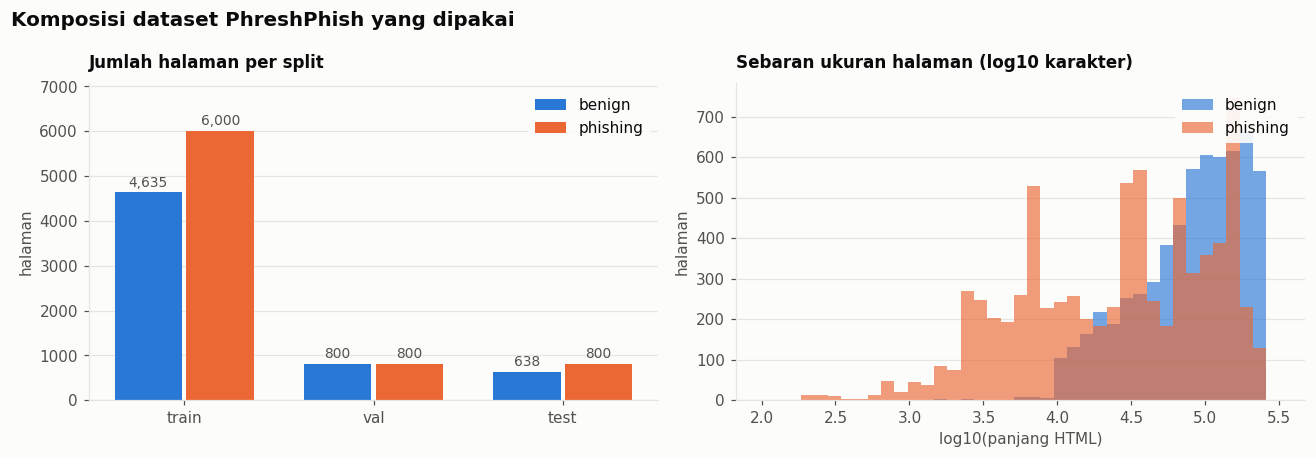

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

# --- panel 1: jumlah halaman per split & label ---
counts = meta.groupby(["split", "label"]).size().unstack(fill_value=0).reindex(["train", "val", "test"])
x = np.arange(len(counts))
width = 0.38
for offset, (label, color) in zip((-width / 2, width / 2), [("benign", TRAIN_C), ("phish", VAL_C)]):
    values = counts[label].to_numpy()
    ax1.bar(x + offset, values, width * 0.94, label=ID2LABEL[SOURCE_LABEL_TO_ID[label]], color=color)
    for xi, value in zip(x + offset, values):
        ax1.annotate(f"{value:,}", (xi, value), xytext=(0, 4), textcoords="offset points",
                     ha="center", fontsize=9, color=INK_SOFT)
ax1.set_xticks(x, counts.index)
legend_in(ax1)
tidy(ax1, "Jumlah halaman per split", ylabel="halaman")
ax1.set_ylim(0, counts.to_numpy().max() * 1.18)

# --- panel 2: sebaran panjang HTML per kelas ---
bins = np.linspace(2, 5.5, 40)
for label, color in [("benign", TRAIN_C), ("phish", VAL_C)]:
    values = np.log10(meta.loc[meta.label == label, "html_len"].clip(lower=1))
    ax2.hist(values, bins=bins, color=color, alpha=0.65, label=ID2LABEL[SOURCE_LABEL_TO_ID[label]])
legend_in(ax2)
tidy(ax2, "Sebaran ukuran halaman (log10 karakter)", xlabel="log10(panjang HTML)", ylabel="halaman")

fig.suptitle("Komposisi dataset PhreshPhish yang dipakai", x=0.007, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout()
save_fig(fig, "01_dataset")
plt.show()

Dua histogram yang **saling menumpuk** justru kabar baik: artinya ukuran halaman
bukan jalan pintas untuk membedakan kelas, jadi apa pun yang dipelajari model nanti
datang dari struktur DOM dan teksnya, bukan dari panjang file.

## 7. Preprocessing: HTML → (nodes, xpaths)

MarkupLM tidak makan HTML mentah. `MarkupLMFeatureExtractor` memecah halaman menjadi
pasangan **teks node** dan **XPath**-nya, lalu XPath itu di-embed sebagai sinyal
struktur di samping token teks — inilah yang membuat model bisa membedakan
"password field di dalam form ke domain lain" dari "kata *password* di artikel blog".

HTML dunia nyata kadang gagal di-parse; halaman seperti itu dilewati dan dihitung,
tidak membuat seluruh run gagal. Setelah parsing, HTML mentah dibuang dari memori.

In [20]:
feature_extractor = MarkupLMFeatureExtractor()


def build_examples(rows: list[dict], split_name: str) -> list[dict]:
    examples: list[dict] = []
    failures = 0
    started = time.monotonic()

    for row in tqdm(rows, desc=f"parse {split_name}", leave=False):
        try:
            encoding = feature_extractor(row["html"])
        except Exception:  # markup rusak: dihitung, lalu lanjut
            failures += 1
            continue
        nodes = encoding["nodes"][0]
        xpaths = encoding["xpaths"][0]
        if not nodes:
            failures += 1
            continue
        # Node di luar max_nodes tidak akan pernah masuk ke 512 token pertama,
        # jadi dipotong di sini: hemat RAM tanpa mengubah input model.
        nodes = nodes[: cfg.max_nodes]
        xpaths = xpaths[: cfg.max_nodes]
        examples.append(
            {
                "nodes": [nodes],
                "xpaths": [xpaths],
                "label_id": row["label_id"],
                "url": row["url"],
            }
        )

    counts = defaultdict(int)
    for example in examples:
        counts[ID2LABEL[example["label_id"]]] += 1
    print(
        f"{split_name}: {len(examples)} halaman siap {dict(counts)} "
        f"({failures} dilewati) dalam {time.monotonic() - started:.0f}s"
    )
    return examples


train_data = build_examples(train_rows, "train")
val_data = build_examples(val_rows, "val")
test_data = build_examples(test_rows, "test")

# HTML mentah tidak dibutuhkan lagi -> bebaskan RAM sebelum training.
for rows in (train_rows, val_rows, test_rows):
    rows.clear()
gc.collect()

print("\ncontoh node pertama dari satu halaman train:")
print(train_data[0]["nodes"][0][:6])
print(train_data[0]["xpaths"][0][:3])

parse train:   0%|          | 0/10635 [00:00<?, ?it/s]

train: 10595 halaman siap {'phishing': 5963, 'benign': 4632} (40 dilewati) dalam 350s


parse val:   0%|          | 0/1600 [00:00<?, ?it/s]

val: 1593 halaman siap {'phishing': 794, 'benign': 799} (7 dilewati) dalam 54s


parse test:   0%|          | 0/1438 [00:00<?, ?it/s]

test: 1437 halaman siap {'phishing': 799, 'benign': 638} (1 dilewati) dalam 44s

contoh node pertama dari satu halaman train:
['M𝐞tåMäsk 𝗟𝗼𝗴𝗶𝗻 | us', ':root {\n                        --primary-color-50: 235 240 251;\n--primary-color-100: 214 226 248;\n--primary-color-200: 174 197 241;\n--primary-color-300: 133 167 233;\n--primary-color-400: 93 138 226;\n--primary-color-500: 52 109 219;\n--primary-color-600: 42 87 175;\n--primary-color-700: 31 65 131;\n--primary-color-800: 21 44 88;\n--primary-color-900: 10 22 44;\n                        --primary-base-50: 235 240 251;\n--primary-base-100: 214 226 248;\n--primary-base-200: 174 197 241;\n--primary-base-300: 133 167 233;\n--primary-base-400: 93 138 226;\n--primary-base-500: 52 109 219;\n--primary-base-600: 42 87 175;\n--primary-base-700: 31 65 131;\n--primary-base-800: 21 44 88;\n--primary-base-900: 10 22 44;\n                        --header-background-50: 255 255 255;\n--header-background-100: 255 255 255;\n--header-background-200: 25

## 8. Dataset & DataLoader PyTorch

Satu halaman → **satu label** (`benign`/`phishing`). Tokenisasi dilakukan di
`__getitem__` supaya tidak perlu menyimpan 13.000 tensor 512-token di RAM.

> Pesan `Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__> ...
> AssertionError: can only test a child process` adalah **noise saat worker DataLoader
> dibersihkan**, bukan kegagalan training. `persistent_workers=True` di bawah menekannya;
> kalau masih mengganggu, set `num_workers = 0` di `Config` (sedikit lebih lambat).

In [21]:
processor = MarkupLMProcessor.from_pretrained(BASE_MODEL)
processor.parse_html = False  # HTML sudah dipecah jadi nodes/xpaths di section 7


class HtmlPhishingDataset(Dataset):
    """Sequence classification: satu halaman HTML -> satu label."""

    def __init__(self, data, processor, max_length=512):
        self.data = data
        self.processor = processor
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        encoding = self.processor(
            nodes=item["nodes"],
            xpaths=item["xpaths"],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )
        encoding = {key: value.squeeze(0) for key, value in encoding.items()}
        encoding["labels"] = torch.tensor(item["label_id"], dtype=torch.long)
        return encoding


def make_loader(data, batch_size, shuffle):
    return DataLoader(
        HtmlPhishingDataset(data, processor, cfg.max_length),
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=cfg.num_workers,
        persistent_workers=cfg.num_workers > 0,  # worker tidak di-spawn ulang tiap epoch
        pin_memory=device.type == "cuda",
        drop_last=False,
    )


train_loader = make_loader(train_data, cfg.batch_size, shuffle=True)
val_loader = make_loader(val_data, cfg.eval_batch_size, shuffle=False)
test_loader = make_loader(test_data, cfg.eval_batch_size, shuffle=False)

batch = next(iter(train_loader))
print("key batch     :", sorted(batch.keys()))
print("bentuk tensor :", {k: tuple(v.shape) for k, v in batch.items()})
print("step per epoch:", len(train_loader))

key batch     : ['attention_mask', 'input_ids', 'labels', 'token_type_ids', 'xpath_subs_seq', 'xpath_tags_seq']
bentuk tensor : {'input_ids': (8, 512), 'token_type_ids': (8, 512), 'attention_mask': (8, 512), 'xpath_tags_seq': (8, 512, 50), 'xpath_subs_seq': (8, 512, 50), 'labels': (8,)}
step per epoch: 1325


## 9. Model, optimizer, scheduler

`MarkupLMForSequenceClassification` = MarkupLM base + head klasifikasi baru
(2 kelas). Peringatan "newly initialized classifier" memang diharapkan: head itulah
yang kita latih.

> **Kenapa ada `.float()`.** `config.json` milik `microsoft/markuplm-base` menulis
> `"torch_dtype": "float16"`, dan sebagian versi `transformers` menurutinya — bobot
> termuat setengah presisi. Padahal resep AMP yang benar adalah **bobot fp32 +
> `autocast` fp16**; kalau bobotnya sendiri fp16, `GradScaler.unscale_()` berhenti
> dengan `ValueError: Attempting to unscale FP16 gradients`. `.float()` mengunci fp32
> tanpa bergantung versi library.

In [22]:
def new_model():
    model = MarkupLMForSequenceClassification.from_pretrained(
        BASE_MODEL, num_labels=2, id2label=ID2LABEL, label2id=LABEL2ID
    )
    # config.json milik markuplm-base menulis "torch_dtype": "float16", dan
    # sebagian versi transformers menurutinya saat memuat bobot. Untuk AMP,
    # master weight WAJIB fp32 (autocast yang mengurus perhitungan fp16-nya);
    # kalau bobotnya sendiri fp16, GradScaler gagal dengan
    # "Attempting to unscale FP16 gradients". .float() memaksa fp32 di semua versi.
    return model.float().to(device)


def new_optimizer(model, lr):
    # Bias dan LayerNorm tidak ikut weight decay (resep standar BERT-family).
    decay, no_decay = [], []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        (no_decay if name.endswith("bias") or "LayerNorm" in name else decay).append(param)
    return AdamW(
        [{"params": decay, "weight_decay": cfg.weight_decay}, {"params": no_decay, "weight_decay": 0.0}],
        lr=lr,
    )


model = new_model()
total_params = sum(p.numel() for p in model.parameters())
print(f"parameter : {total_params / 1e6:.1f}M")
print("dtype     :", next(model.parameters()).dtype, "(harus torch.float32 supaya AMP aman)")

Loading weights:   0%|          | 0/305 [00:00<?, ?it/s]

Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 116, in auto_conversion
    raise e
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 95, in auto_conversion
    sha = get_conversion_pr_reference(api, pretrained_model_name_or_path, **cached_file_kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 71, in get_conversion_pr_reference
    spawn_conversion(token, private, model_id)
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 48, in spawn_con

parameter : 135.2M
dtype     : torch.float32 (harus torch.float32 supaya AMP aman)


## 10. Fungsi evaluasi & training loop

`train_loop` dipakai tiga kali: sekali untuk run utama dan dua kali untuk kontrol
eksperimen di section 13. Yang dicatat tiap epoch: loss train, loss validasi,
akurasi, precision/recall/F1 kelas phishing, dan ROC-AUC.

Evaluasi **juga dijalankan sebelum epoch pertama** (epoch 0 = bobot acak). Tanpa titik
awal ini, grafik tidak bisa membuktikan apa pun — kita tidak tahu dari mana model mulai.

In [23]:
def amp_ctx():
    return torch.amp.autocast("cuda", dtype=torch.float16) if USE_AMP else nullcontext()


def metrics_from(labels, probs, threshold=0.5) -> dict:
    labels = np.asarray(labels)
    probs = np.asarray(probs)
    preds = (probs >= threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", pos_label=1, zero_division=0
    )
    # AUC tidak terdefinisi kalau hanya ada satu kelas di batch evaluasi.
    auc = roc_auc_score(labels, probs) if len(set(labels.tolist())) > 1 else float("nan")
    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc,
    }


@torch.no_grad()
def evaluate(model, loader, desc="eval"):
    model.eval()
    total_loss, total_n = 0.0, 0
    probs, labels = [], []

    for batch in tqdm(loader, desc=desc, leave=False):
        inputs = {key: value.to(device, non_blocking=True) for key, value in batch.items()}
        with amp_ctx():
            outputs = model(**inputs)
        n = inputs["labels"].size(0)
        total_loss += outputs.loss.item() * n
        total_n += n
        probs.extend(torch.softmax(outputs.logits.float(), dim=-1)[:, 1].cpu().tolist())
        labels.extend(batch["labels"].tolist())

    result = metrics_from(labels, probs)
    result["loss"] = total_loss / max(total_n, 1)
    result["n"] = total_n
    return result, np.asarray(probs), np.asarray(labels)


def train_loop(model, train_loader, val_loader, epochs, lr, tag="run", checkpoint_path=None):
    """Latih model; kembalikan riwayat per epoch + loss per step."""
    optimizer = new_optimizer(model, lr)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer, int(total_steps * cfg.warmup_ratio), total_steps
    )
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

    history, step_losses, lr_trace = [], [], []
    best_f1 = -1.0

    # Epoch 0 = bobot acak, patokan "belum belajar apa-apa".
    start_metrics, _, _ = evaluate(model, val_loader, desc=f"{tag} epoch 0 (acak)")
    history.append({"epoch": 0, "train_loss": float("nan"), **{f"val_{k}": v for k, v in start_metrics.items()}})
    print(f"[{tag}] epoch 0 (bobot acak): val_loss={start_metrics['loss']:.4f} "
          f"acc={start_metrics['accuracy']:.3f} f1={start_metrics['f1']:.3f} auc={start_metrics['auc']:.3f}")

    for epoch in range(1, epochs + 1):
        model.train()
        running, seen = 0.0, 0
        started = time.monotonic()

        for batch in tqdm(train_loader, desc=f"{tag} epoch {epoch}", leave=False):
            inputs = {key: value.to(device, non_blocking=True) for key, value in batch.items()}
            optimizer.zero_grad(set_to_none=True)
            with amp_ctx():
                outputs = model(**inputs)
            loss = outputs.loss
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            step_losses.append(loss.item())
            lr_trace.append(scheduler.get_last_lr()[0])
            running += loss.item() * inputs["labels"].size(0)
            seen += inputs["labels"].size(0)

        train_loss = running / max(seen, 1)
        val_metrics, _, _ = evaluate(model, val_loader, desc=f"{tag} val {epoch}")
        history.append({"epoch": epoch, "train_loss": train_loss,
                        **{f"val_{k}": v for k, v in val_metrics.items()}})
        print(f"[{tag}] epoch {epoch}: train_loss={train_loss:.4f} val_loss={val_metrics['loss']:.4f} "
              f"acc={val_metrics['accuracy']:.3f} f1={val_metrics['f1']:.3f} auc={val_metrics['auc']:.3f} "
              f"({time.monotonic() - started:.0f}s)")

        # Checkpoint yang disimpan = epoch terbaik menurut F1 validasi, bukan epoch terakhir.
        if checkpoint_path is not None and val_metrics["f1"] > best_f1:
            best_f1 = val_metrics["f1"]
            torch.save(model.state_dict(), checkpoint_path)
            print(f"        -> checkpoint baru (F1 val {best_f1:.3f})")

    return pd.DataFrame(history), step_losses, lr_trace

## 11. Training

Dengan konfigurasi default ini ±1.700 step per epoch. Progress bar tiap epoch,
lalu satu baris metrik validasi.

In [24]:
started = time.monotonic()
history, step_losses, lr_trace = train_loop(
    model,
    train_loader,
    val_loader,
    epochs=cfg.epochs,
    lr=cfg.learning_rate,
    tag="main",
    checkpoint_path=CKPT_PATH,
)
print(f"\nselesai dalam {(time.monotonic() - started) / 60:.1f} menit")
history.round(4)

main epoch 0 (acak):   0%|          | 0/100 [00:00<?, ?it/s]

[main] epoch 0 (bobot acak): val_loss=0.7313 acc=0.476 f1=0.633 auc=0.358


main epoch 1:   0%|          | 0/1325 [00:00<?, ?it/s]

main val 1:   0%|          | 0/100 [00:00<?, ?it/s]

[main] epoch 1: train_loss=0.3822 val_loss=0.2690 acc=0.905 f1=0.902 auc=0.969 (530s)
        -> checkpoint baru (F1 val 0.902)


...

[main] epoch 3: train_loss=0.1164 val_loss=0.4178 acc=0.922 f1=0.924 auc=0.976 (530s)
        -> checkpoint baru (F1 val 0.924)


main epoch 4:   0%|          | 0/1325 [00:00<?, ?it/s]

main val 4:   0%|          | 0/100 [00:00<?, ?it/s]

[main] epoch 4: train_loss=0.0694 val_loss=0.4604 acc=0.923 f1=0.923 auc=0.975 (528s)

selesai dalam 36.2 menit


,epoch,train_loss,val_accuracy,val_precision,val_recall,val_f1,val_auc,val_loss,val_n
0,0,NaN,0.4765,0.4864,0.9043,0.6326,0.3577,0.7313,1593
1,1,0.3822,0.9052,0.9350,0.8703,0.9015,0.9693,0.2690,1593
2,2,0.2005,0.9171,0.9046,0.9320,0.9181,0.9743,0.3757,1593
3,3,0.1164,0.9222,0.8998,0.9496,0.9240,0.9758,0.4178,1593
4,4,0.0694,0.9228,0.9157,0.9307,0.9232,0.9752,0.4604,1593


## 12. Grafik epoch: apakah model benar-benar belajar?

Tiga panel, masing-masing menjawab satu pertanyaan berbeda:

1. **Loss train vs validasi** — kurva train turun = model menyerap data latih;
   kurva validasi turun bersamaan = yang diserap bisa dipakai di halaman yang belum
   pernah dilihat. Kalau train turun tapi validasi naik, itu overfitting, bukan belajar.
2. **Metrik validasi per epoch** — F1/akurasi/AUC harus bergerak jelas di atas titik
   epoch 0 (bobot acak, garis putus-putus abu).
3. **Loss per step** — kalau panel 1 terlihat mulus tapi panel ini berantakan,
   learning rate terlalu besar.

grafik disimpan: /kaggle/working/markuplm-phishing-classifier/figures/02_training_curves.png


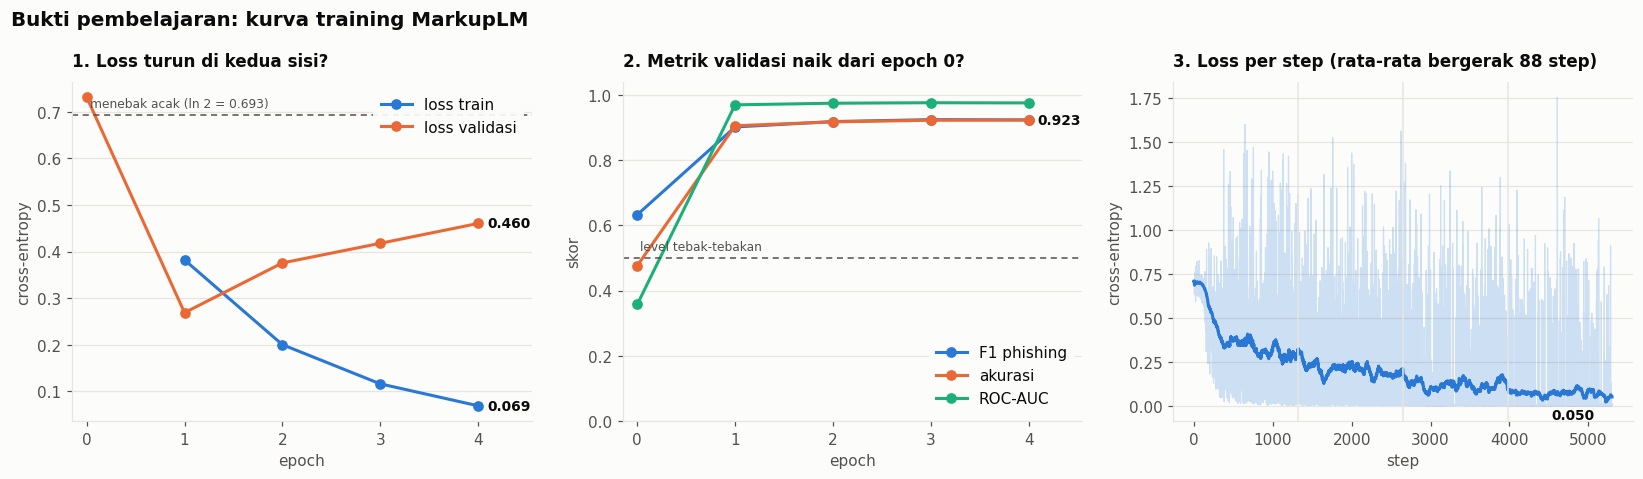

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
epochs_axis = history["epoch"].to_numpy()

# --- panel 1: loss ---
ax = axes[0]
ax.plot(epochs_axis, history["train_loss"], color=TRAIN_C, marker="o", label="loss train")
ax.plot(epochs_axis, history["val_loss"], color=VAL_C, marker="o", label="loss validasi")
last = int(epochs_axis[-1])
end_label(ax, last, history["train_loss"].iloc[-1], f"{history['train_loss'].iloc[-1]:.3f}")
end_label(ax, last, history["val_loss"].iloc[-1], f"{history['val_loss'].iloc[-1]:.3f}")
ax.axhline(math.log(2), color=INK_SOFT, linestyle=(0, (4, 3)), linewidth=1)
ax.annotate("menebak acak (ln 2 = 0.693)", (epochs_axis[0], math.log(2)), xytext=(2, 5),
            textcoords="offset points", fontsize=8, color=INK_SOFT)
legend_in(ax)
tidy(ax, "1. Loss turun di kedua sisi?", xlabel="epoch", ylabel="cross-entropy")
ax.set_xticks(epochs_axis)
ax.set_xlim(-0.15, last + 0.55)

# --- panel 2: metrik validasi ---
ax = axes[1]
for column, color, name in [("val_f1", TRAIN_C, "F1 phishing"), ("val_accuracy", VAL_C, "akurasi"), ("val_auc", TEST_C, "ROC-AUC")]:
    ax.plot(epochs_axis, history[column], color=color, marker="o", label=name)
end_label(ax, last, history["val_f1"].iloc[-1], f"{history['val_f1'].iloc[-1]:.3f}")
ax.axhline(0.5, color=INK_SOFT, linestyle=(0, (4, 3)), linewidth=1)
ax.annotate("level tebak-tebakan", (epochs_axis[0], 0.5), xytext=(2, 5), textcoords="offset points",
            fontsize=8, color=INK_SOFT)
legend_in(ax, "lower right")
tidy(ax, "2. Metrik validasi naik dari epoch 0?", xlabel="epoch", ylabel="skor")
ax.set_xticks(epochs_axis)
ax.set_ylim(0, 1.04)
ax.set_xlim(-0.15, last + 0.55)

# --- panel 3: loss per step ---
ax = axes[2]
steps = np.arange(1, len(step_losses) + 1)
window = max(len(step_losses) // 60, 10)
smooth = pd.Series(step_losses).rolling(window, min_periods=1).mean()
ax.plot(steps, step_losses, color=TRAIN_C, alpha=0.22, linewidth=0.8)
ax.plot(steps, smooth, color=TRAIN_C, linewidth=2)
end_label(ax, steps[-1], smooth.iloc[-1], f"{smooth.iloc[-1]:.3f}", dx=-40, dy=-12)
for boundary in range(1, cfg.epochs):
    ax.axvline(boundary * len(train_loader), color=GRID, linewidth=1)
tidy(ax, f"3. Loss per step (rata-rata bergerak {window} step)", xlabel="step", ylabel="cross-entropy")

fig.suptitle("Bukti pembelajaran: kurva training MarkupLM", x=0.007, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout()
save_fig(fig, "02_training_curves")
plt.show()

### Diagnosa otomatis

Daripada menatap grafik dan berharap, cell di bawah memeriksa syarat-syaratnya satu
per satu dan mencetak lulus/tidak.

In [26]:
base = history.iloc[0]
best_row = history.loc[history["val_f1"].idxmax()]
trained = history.iloc[1:]

checks = []

checks.append((
    "Loss train menurun dibanding epoch pertama",
    trained["train_loss"].iloc[-1] < trained["train_loss"].iloc[0],
    f"{trained['train_loss'].iloc[0]:.4f} -> {trained['train_loss'].iloc[-1]:.4f}",
))
checks.append((
    "Loss validasi lebih baik daripada bobot acak",
    best_row["val_loss"] < base["val_loss"],
    f"{base['val_loss']:.4f} (acak) -> {best_row['val_loss']:.4f} (terbaik)",
))
checks.append((
    "F1 validasi jauh di atas level tebak-tebakan",
    best_row["val_f1"] > 0.70,
    f"F1 terbaik {best_row['val_f1']:.3f} pada epoch {int(best_row['epoch'])}",
))
checks.append((
    "ROC-AUC validasi > 0.85 (pemisahan kelas nyata)",
    best_row["val_auc"] > 0.85,
    f"AUC terbaik {trained['val_auc'].max():.3f}",
))
gap = trained["val_loss"].iloc[-1] - trained["train_loss"].iloc[-1]
checks.append((
    "Jarak loss validasi-train masih wajar (< 0.35)",
    gap < 0.35,
    f"gap epoch terakhir {gap:+.3f}",
))
val_loss_rising = trained["val_loss"].iloc[-1] > trained["val_loss"].min() + 0.05
checks.append((
    "Loss validasi belum berbalik naik (belum overfit)",
    not val_loss_rising,
    f"min {trained['val_loss'].min():.4f} pada epoch {int(trained.loc[trained['val_loss'].idxmin(), 'epoch'])}, "
    f"terakhir {trained['val_loss'].iloc[-1]:.4f}",
))

width = max(len(name) for name, _, _ in checks)
for name, passed, detail in checks:
    print(f"{'LULUS ' if passed else 'PERIKSA'} | {name.ljust(width)} | {detail}")

print("\nKesimpulan:", "model belajar sinyal yang bisa digeneralisasi."
      if sum(p for _, p, _ in checks) >= 5 else
      "ada syarat yang belum lulus - baca kolom terakhir, lalu ubah epoch/learning rate/ukuran data.")

LULUS  | Loss train menurun dibanding epoch pertama        | 0.3822 -> 0.0694
LULUS  | Loss validasi lebih baik daripada bobot acak      | 0.7313 (acak) -> 0.4178 (terbaik)
LULUS  | F1 validasi jauh di atas level tebak-tebakan      | F1 terbaik 0.924 pada epoch 3
LULUS  | ROC-AUC validasi > 0.85 (pemisahan kelas nyata)   | AUC terbaik 0.976
PERIKSA | Jarak loss validasi-train masih wajar (< 0.35)    | gap epoch terakhir +0.391
PERIKSA | Loss validasi belum berbalik naik (belum overfit) | min 0.2690 pada epoch 1, terakhir 0.4604

Kesimpulan: ada syarat yang belum lulus - baca kolom terakhir, lalu ubah epoch/learning rate/ukuran data.


## 13. Kontrol eksperimen: label diacak

Kurva yang bagus masih bisa menipu — bisa jadi pipeline-nya yang bocor, bukan modelnya
yang pintar. Uji standarnya: latih ulang model **dari nol** pada subset kecil yang sama,
sekali dengan label asli dan sekali dengan **label training diacak**. Data validasinya
tetap bersih di kedua run.

Yang seharusnya terjadi:

* **Label asli** → F1 validasi naik.
* **Label diacak** → F1 validasi menempel di level tebak-tebakan, karena tidak ada pola
  yang bisa dipelajari. Kalau run ini *juga* bagus, berarti ada kebocoran label di
  pipeline dan semua angka sebelumnya tidak bisa dipercaya.

In [27]:
control_train = train_data[: cfg.control_subset]
control_val = val_data[: min(len(val_data), 400)]

# Salinan dengan label training diacak (data validasi tidak disentuh).
shuffled_train = [dict(item) for item in control_train]
shuffled_ids = [item["label_id"] for item in shuffled_train]
random.Random(cfg.seed).shuffle(shuffled_ids)
for item, label_id in zip(shuffled_train, shuffled_ids):
    item["label_id"] = label_id

agreement = np.mean([a["label_id"] == b["label_id"] for a, b in zip(control_train, shuffled_train)])
print(f"subset kontrol: {len(control_train)} halaman train, {len(control_val)} halaman val")
print(f"label yang kebetulan tetap sama setelah diacak: {agreement:.1%} (wajar di sekitar 50%)")

control_val_loader = make_loader(control_val, cfg.eval_batch_size, shuffle=False)
control_histories = {}

for name, data in [("label asli", control_train), ("label diacak", shuffled_train)]:
    print(f"\n=== run kontrol: {name} ===")
    torch.manual_seed(cfg.seed)  # dua run start dari head klasifikasi yang sama
    control_model = new_model()
    control_loader = make_loader(data, cfg.batch_size, shuffle=True)
    control_histories[name], _, _ = train_loop(
        control_model, control_loader, control_val_loader,
        epochs=cfg.control_epochs, lr=cfg.learning_rate, tag=name,
    )
    del control_model, control_loader
    gc.collect()
    if device.type == "cuda":
        torch.cuda.empty_cache()

subset kontrol: 600 halaman train, 400 halaman val
label yang kebetulan tetap sama setelah diacak: 51.7% (wajar di sekitar 50%)

=== run kontrol: label asli ===


Loading weights:   0%|          | 0/305 [00:00<?, ?it/s]

Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 116, in auto_conversion
    raise e
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 95, in auto_conversion
    sha = get_conversion_pr_reference(api, pretrained_model_name_or_path, **cached_file_kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 71, in get_conversion_pr_reference
    spawn_conversion(token, private, model_id)
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 48, in spawn_con

label asli epoch 0 (acak):   0%|          | 0/25 [00:00<?, ?it/s]

[label asli] epoch 0 (bobot acak): val_loss=0.6683 acc=0.593 f1=0.649 auc=0.658


...

label diacak val 2:   0%|          | 0/25 [00:00<?, ?it/s]

[label diacak] epoch 2: train_loss=0.6860 val_loss=0.6908 acc=0.555 f1=0.631 auc=0.538 (43s)


label diacak epoch 3:   0%|          | 0/75 [00:00<?, ?it/s]

label diacak val 3:   0%|          | 0/25 [00:00<?, ?it/s]

[label diacak] epoch 3: train_loss=0.6504 val_loss=0.6979 acc=0.555 f1=0.660 auc=0.545 (42s)


grafik disimpan: /kaggle/working/markuplm-phishing-classifier/figures/03_label_shuffle_control.png


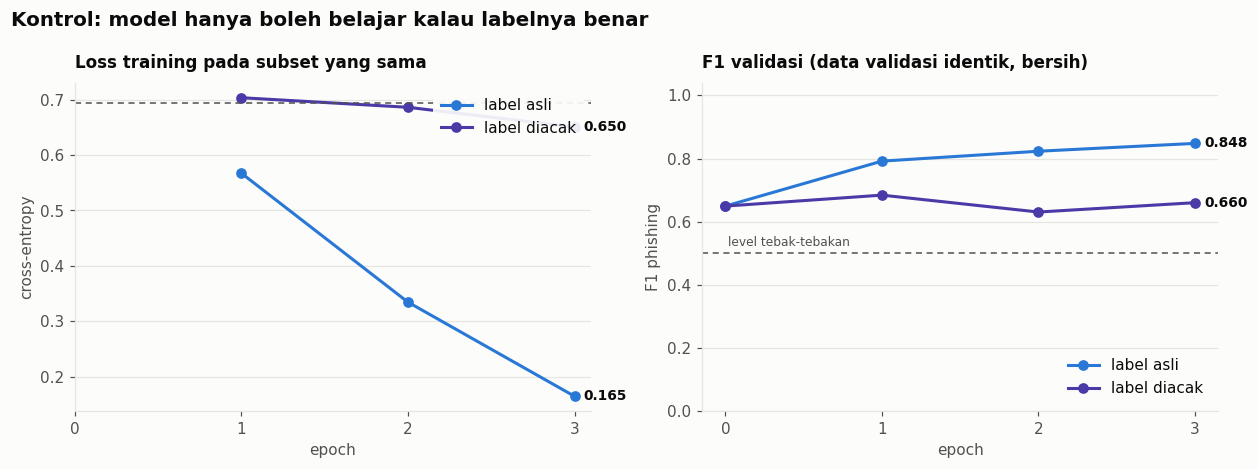

F1 validasi terbaik - label asli: 0.848 | label diacak: 0.684
VALID   : sinyalnya nyata, bukan kebocoran pipeline.


In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.3))
styles = {"label asli": TRAIN_C, "label diacak": CTRL_C}

for name, frame in control_histories.items():
    color = styles[name]
    ax1.plot(frame["epoch"], frame["train_loss"], color=color, marker="o", label=name)
    ax2.plot(frame["epoch"], frame["val_f1"], color=color, marker="o", label=name)
    end_label(ax1, frame["epoch"].iloc[-1], frame["train_loss"].iloc[-1], f"{frame['train_loss'].iloc[-1]:.3f}")
    end_label(ax2, frame["epoch"].iloc[-1], frame["val_f1"].iloc[-1], f"{frame['val_f1'].iloc[-1]:.3f}")

ax1.axhline(math.log(2), color=INK_SOFT, linestyle=(0, (4, 3)), linewidth=1)
legend_in(ax1)
tidy(ax1, "Loss training pada subset yang sama", xlabel="epoch", ylabel="cross-entropy")

ax2.axhline(0.5, color=INK_SOFT, linestyle=(0, (4, 3)), linewidth=1)
ax2.annotate("level tebak-tebakan", (0, 0.5), xytext=(2, 5), textcoords="offset points",
             fontsize=8, color=INK_SOFT)
legend_in(ax2, "lower right")
tidy(ax2, "F1 validasi (data validasi identik, bersih)", xlabel="epoch", ylabel="F1 phishing")
ax2.set_ylim(0, 1.04)

for ax in (ax1, ax2):
    ax.set_xticks(control_histories["label asli"]["epoch"].to_numpy())

fig.suptitle("Kontrol: model hanya boleh belajar kalau labelnya benar", x=0.007, ha="left",
             fontsize=13, fontweight="bold")
fig.tight_layout()
save_fig(fig, "03_label_shuffle_control")
plt.show()

real_best = control_histories["label asli"]["val_f1"].max()
fake_best = control_histories["label diacak"]["val_f1"].max()
print(f"F1 validasi terbaik - label asli: {real_best:.3f} | label diacak: {fake_best:.3f}")
print("VALID   : sinyalnya nyata, bukan kebocoran pipeline."
      if real_best - fake_best > 0.15 else
      "WASPADA : selisihnya terlalu kecil. Cek ulang split data dan naikkan control_subset.")

## 14. Evaluasi akhir di test set

Checkpoint yang dipakai adalah **epoch dengan F1 validasi terbaik**, bukan epoch terakhir.
Threshold keputusan juga di-tuning di **validasi** (bukan di test) — kalau threshold
dicari di test set, angka yang dilaporkan sudah tidak jujur lagi.

In [29]:
model.load_state_dict(torch.load(CKPT_PATH, map_location=device))
model.to(device)
print("checkpoint terbaik dimuat:", CKPT_PATH)

val_metrics, val_probs, val_labels = evaluate(model, val_loader, desc="val final")
test_metrics, test_probs, test_labels = evaluate(model, test_loader, desc="test")

# Threshold terbaik menurut F1 di validasi.
precisions, recalls, thresholds = precision_recall_curve(val_labels, val_probs)
f1_curve = np.divide(2 * precisions * recalls, precisions + recalls,
                     out=np.zeros_like(precisions), where=(precisions + recalls) > 0)
best_threshold = float(thresholds[int(np.argmax(f1_curve[:-1]))])
print(f"threshold terbaik dari validasi: {best_threshold:.3f} (F1 val {f1_curve.max():.3f})")

rows = [
    {"set": "validasi", "threshold": 0.5, **metrics_from(val_labels, val_probs, 0.5)},
    {"set": "validasi", "threshold": best_threshold, **metrics_from(val_labels, val_probs, best_threshold)},
    {"set": "test", "threshold": 0.5, **metrics_from(test_labels, test_probs, 0.5)},
    {"set": "test", "threshold": best_threshold, **metrics_from(test_labels, test_probs, best_threshold)},
]
scoreboard = pd.DataFrame(rows).round(4)
display(scoreboard)

test_preds = (test_probs >= best_threshold).astype(int)
print(f"\nclassification report - test set @ threshold {best_threshold:.3f}")
print(classification_report(test_labels, test_preds, target_names=["benign", "phishing"], digits=3))

checkpoint terbaik dimuat: /tmp/best_state.pt


val final:   0%|          | 0/100 [00:00<?, ?it/s]

test:   0%|          | 0/90 [00:00<?, ?it/s]

threshold terbaik dari validasi: 0.751 (F1 val 0.926)


,set,threshold,accuracy,precision,recall,f1,auc
0,validasi,0.500,0.9222,0.8998,0.9496,0.9240,0.9758
1,validasi,0.751,0.9240,0.9040,0.9484,0.9256,0.9758
2,test,0.500,0.8351,0.9132,0.7772,0.8398,0.9259
3,test,0.751,0.8344,0.9180,0.7710,0.8381,0.9259



classification report - test set @ threshold 0.751
              precision    recall  f1-score   support

      benign      0.761     0.914     0.830       638
    phishing      0.918     0.771     0.838       799

    accuracy                          0.834      1437
   macro avg      0.840     0.842     0.834      1437
weighted avg      0.848     0.834     0.835      1437



grafik disimpan: /kaggle/working/markuplm-phishing-classifier/figures/04_test_evaluation.png


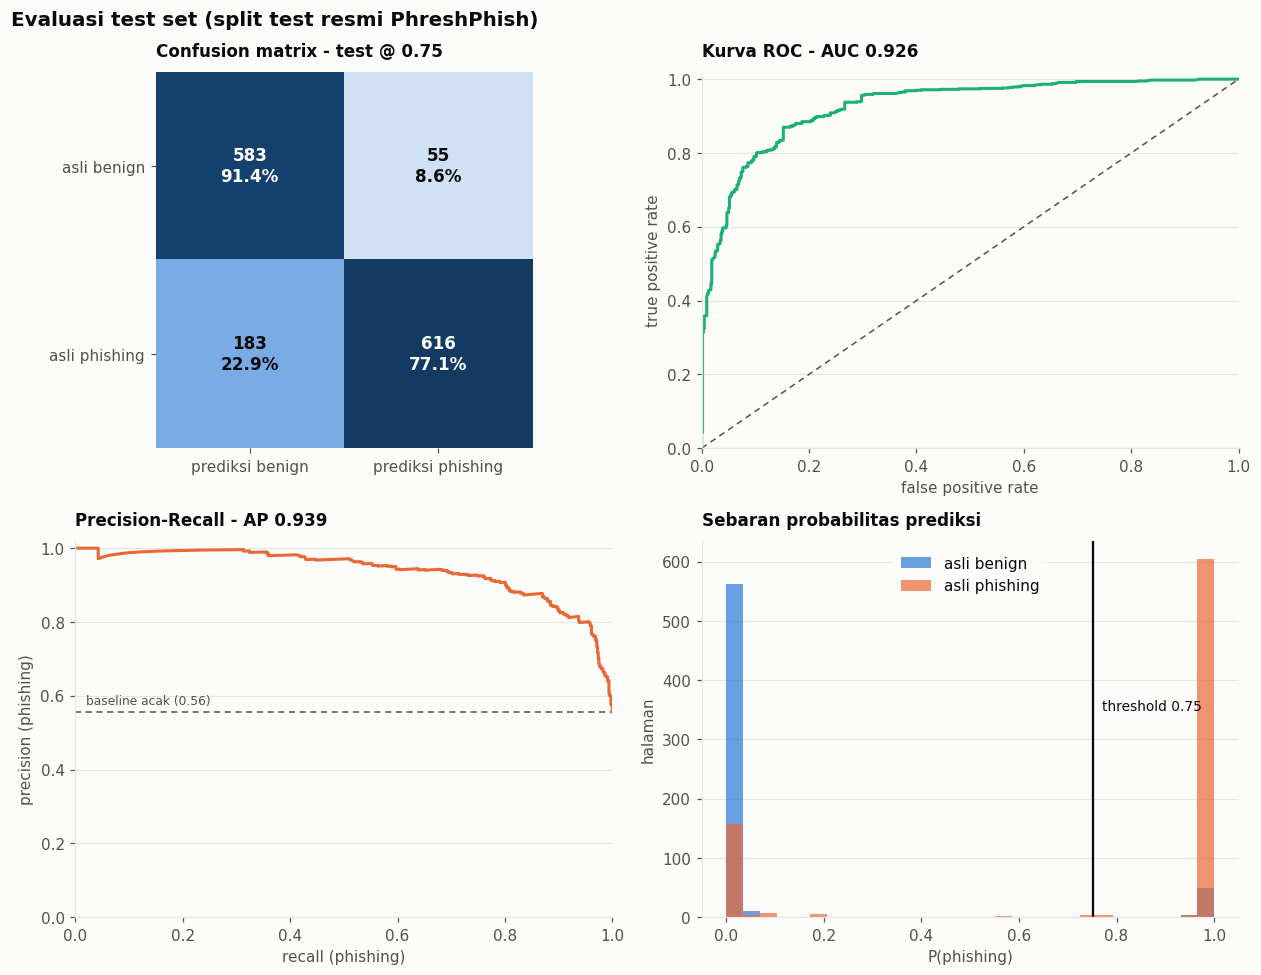

In [30]:
cm = confusion_matrix(test_labels, test_preds)
fpr, tpr, _ = roc_curve(test_labels, test_probs)
test_auc = roc_auc_score(test_labels, test_probs)
prec_t, rec_t, _ = precision_recall_curve(test_labels, test_probs)
ap = average_precision_score(test_labels, test_probs)
prevalence = float(np.mean(test_labels))

fig, axes = plt.subplots(2, 2, figsize=(11.5, 9))

# --- confusion matrix (satu hue, terang -> gelap) ---
ax = axes[0, 0]
ax.imshow(cm, cmap=BLUES, vmin=0, vmax=cm.max())
ax.set_xticks([0, 1], ["prediksi benign", "prediksi phishing"])
ax.set_yticks([0, 1], ["asli benign", "asli phishing"])
ax.grid(False)
for i in range(2):
    for j in range(2):
        share = cm[i, j] / cm[i].sum() if cm[i].sum() else 0
        ax.annotate(f"{cm[i, j]:,}\n{share:.1%}", (j, i), ha="center", va="center",
                    color="#ffffff" if cm[i, j] > cm.max() * 0.55 else INK, fontsize=11, fontweight="bold")
ax.set_title(f"Confusion matrix - test @ {best_threshold:.2f}", pad=10)
for side in ("top", "right", "left", "bottom"):
    ax.spines[side].set_visible(False)

# --- ROC ---
ax = axes[0, 1]
ax.plot([0, 1], [0, 1], color=INK_SOFT, linestyle=(0, (4, 3)), linewidth=1)
ax.plot(fpr, tpr, color=TEST_C)
tidy(ax, f"Kurva ROC - AUC {test_auc:.3f}", xlabel="false positive rate", ylabel="true positive rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)

# --- precision-recall ---
ax = axes[1, 0]
ax.axhline(prevalence, color=INK_SOFT, linestyle=(0, (4, 3)), linewidth=1)
ax.annotate(f"baseline acak ({prevalence:.2f})", (0.02, prevalence), xytext=(0, 5),
            textcoords="offset points", fontsize=8, color=INK_SOFT)
ax.plot(rec_t, prec_t, color=VAL_C)
tidy(ax, f"Precision-Recall - AP {ap:.3f}", xlabel="recall (phishing)", ylabel="precision (phishing)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)

# --- sebaran probabilitas ---
ax = axes[1, 1]
bins = np.linspace(0, 1, 30)
ax.hist(test_probs[test_labels == 0], bins=bins, color=TRAIN_C, alpha=0.7, label="asli benign")
ax.hist(test_probs[test_labels == 1], bins=bins, color=VAL_C, alpha=0.7, label="asli phishing")
ax.axvline(best_threshold, color=INK, linewidth=1.5)
ax.annotate(f"threshold {best_threshold:.2f}", (best_threshold, ax.get_ylim()[1] * 0.55),
            xytext=(6, 0), textcoords="offset points", fontsize=9, color=INK)
legend_in(ax, "upper center")
tidy(ax, "Sebaran probabilitas prediksi", xlabel="P(phishing)", ylabel="halaman")

fig.suptitle("Evaluasi test set (split test resmi PhreshPhish)", x=0.007, ha="left",
             fontsize=13, fontweight="bold")
fig.tight_layout()
save_fig(fig, "04_test_evaluation")
plt.show()

**Cara membaca:** dua histogram di kanan bawah yang menumpuk jadi satu gundukan =
model tidak yakin pada apa pun (walau akurasinya kelihatan oke); dua gundukan yang
terpisah di ujung 0 dan 1 = model benar-benar memisahkan kelas. Baris atas confusion
matrix adalah **false positive** — halaman aman yang diblokir, biaya paling mahal untuk
sebuah ekstensi browser.

## 15. Simpan artifact

Semua masuk ke `/kaggle/working/markuplm-phishing-classifier/`, jadi bisa diunduh dari
tab **Output** notebook Kaggle atau dipakai sebagai input notebook lain.

In [31]:
OUT_DIR.mkdir(parents=True, exist_ok=True)
model.save_pretrained(OUT_DIR)
processor.save_pretrained(OUT_DIR)
history.to_csv(OUT_DIR / "history.csv", index=False)
scoreboard.to_csv(OUT_DIR / "test_scoreboard.csv", index=False)

metadata = {
    "base_model": BASE_MODEL,
    "task": "sequence-classification (benign vs phishing HTML page)",
    "dataset": DATASET_ID,
    "id2label": ID2LABEL,
    "config": asdict(cfg),
    "counts": {"train": len(train_data), "val": len(val_data), "test": len(test_data)},
    "best_epoch": int(history.loc[history["val_f1"].idxmax(), "epoch"]),
    "decision_threshold": best_threshold,
    "val_metrics": {k: float(v) for k, v in val_metrics.items()},
    "test_metrics_at_threshold": {k: float(v) for k, v in metrics_from(test_labels, test_probs, best_threshold).items()},
    "test_auc": float(test_auc),
    "control_check": {
        "real_labels_best_val_f1": float(control_histories["label asli"]["val_f1"].max()),
        "shuffled_labels_best_val_f1": float(control_histories["label diacak"]["val_f1"].max()),
    },
}
(OUT_DIR / "metadata.json").write_text(json.dumps(metadata, indent=2))

print("tersimpan di", OUT_DIR.resolve())
for path in sorted(OUT_DIR.rglob("*")):
    if path.is_file():
        print(f"  {path.relative_to(OUT_DIR)}  ({path.stat().st_size / 1e6:.1f} MB)")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

tersimpan di /kaggle/working/markuplm-phishing-classifier
  config.json  (0.0 MB)
  figures/01_dataset.png  (0.1 MB)
  figures/02_training_curves.png  (0.2 MB)
  figures/03_label_shuffle_control.png  (0.1 MB)
  figures/04_test_evaluation.png  (0.2 MB)
  history.csv  (0.0 MB)
  metadata.json  (0.0 MB)
  model.safetensors  (540.9 MB)
  processor_config.json  (0.0 MB)
  test_scoreboard.csv  (0.0 MB)
  tokenizer.json  (3.6 MB)
  tokenizer_config.json  (0.0 MB)


## 16. Smoke test inference

Muat ulang artifact dari disk (bukan model yang masih di memori) dan jalankan pada dua
halaman buatan. Ini memeriksa jalur *HTML mentah → prediksi* yang nanti dipakai server,
bukan kualitas modelnya.

In [32]:
loaded_processor = MarkupLMProcessor.from_pretrained(OUT_DIR)
loaded_processor.parse_html = True  # di sini kita memang mengirim HTML mentah
loaded_model = MarkupLMForSequenceClassification.from_pretrained(OUT_DIR).float().to(device).eval()


def predict(html: str, threshold: float = best_threshold) -> dict:
    inputs = loaded_processor(
        html, truncation=True, padding="max_length", max_length=cfg.max_length, return_tensors="pt"
    ).to(device)
    with torch.no_grad():
        logits = loaded_model(**inputs).logits.float()
    prob_phishing = torch.softmax(logits, dim=-1)[0, 1].item()
    return {
        "p_phishing": round(prob_phishing, 4),
        "keputusan": ID2LABEL[int(prob_phishing >= threshold)],
    }


samples = {
    "blog biasa": """
    <html><head><title>My Hiking Blog</title></head>
    <body><h1>Welcome</h1><p>Catatan perjalanan naik gunung akhir pekan lalu.</p>
    <a href="/archive">Arsip</a></body></html>
    """,
    "form login palsu": """
    <html><head><title>Verify Your Account - Secure Login</title></head>
    <body>
      <img src="logo.png" alt="PayPal">
      <h2>Your account has been limited. Please verify your identity now.</h2>
      <form action="http://totally-not-paypal.example.ru/collect" method="post">
        <input type="text" name="email" placeholder="Email">
        <input type="password" name="password" placeholder="Password">
        <input type="text" name="card_number" placeholder="Card number">
        <input type="text" name="cvv" placeholder="CVV">
        <button type="submit">Confirm Identity</button>
      </form>
    </body></html>
    """,
    "halaman login asli (mirip, tapi benign)": """
    <html><head><title>Sign in - Example Corp</title></head>
    <body><nav><a href="/help">Bantuan</a><a href="/privacy">Privasi</a></nav>
      <form action="https://accounts.example.com/login" method="post">
        <input type="email" name="email" placeholder="Email">
        <input type="password" name="password" placeholder="Password">
        <button type="submit">Sign in</button>
      </form>
      <footer>© Example Corp</footer></body></html>
    """,
}

for name, html in samples.items():
    print(f"{name:42s} -> {predict(html)}")

Loading weights:   0%|          | 0/307 [00:00<?, ?it/s]

blog biasa                                 -> {'p_phishing': 0.9833, 'keputusan': 'phishing'}
form login palsu                           -> {'p_phishing': 0.9991, 'keputusan': 'phishing'}
halaman login asli (mirip, tapi benign)    -> {'p_phishing': 0.9994, 'keputusan': 'phishing'}


## 17. Kesimpulan & checklist

**Checklist "model benar-benar belajar"** — keempatnya harus lulus, satu saja tidak cukup:

| # | Bukti | Dari section | Tanda lulus |
|---|---|---|---|
| 1 | Loss train **dan** validasi turun bersamaan | 12, panel 1 | keduanya turun; jarak antar keduanya tidak melebar tajam |
| 2 | Metrik validasi bergerak jauh dari epoch 0 | 12, panel 2 | F1 > 0.70 dan AUC > 0.85, epoch 0 ada di sekitar 0.5 |
| 3 | Run label-diacak **gagal** belajar | 13 | selisih F1 val label-asli vs label-diacak > 0.15 |
| 4 | Generalisasi ke test set resmi | 14 | AUC test dekat dengan AUC validasi, dua gundukan probabilitas terpisah |

Kalau grafiknya tidak sesuai harapan:

| Gejala | Kemungkinan | Tindakan |
|---|---|---|
| Loss train datar di ~0.69 | learning rate terlalu kecil / terlalu besar | coba `learning_rate` 3e-5 atau 1e-5 |
| Loss train turun, loss val naik | overfitting | kurangi `epochs`, tambah `train_per_class` |
| Panel 3 sangat berisik | learning rate terlalu besar untuk batch kecil | turunkan LR atau naikkan `batch_size` |
| F1 val bagus, F1 test jatuh | kebocoran domain antar split | cek angka "domain di train DAN val" di section 4 |
| Run label-diacak juga bagus | kebocoran label | jangan percaya angka lain; audit section 4 |
| `ValueError: Attempting to unscale FP16 gradients` | bobot termuat fp16 | sudah dicegah `model.float()` di section 9 — jangan tambahkan `.half()` |
| `AssertionError: can only test a child process` | noise pembersihan worker DataLoader | abaikan, atau set `num_workers = 0` |

**Menaikkan skala.** Semua jalur mahal (unduhan shard, parsing, training) hanya bergantung
pada `Config`: naikkan `train_shards` + `train_per_class` bersamaan (1 shard hanya berisi
±10.000 halaman, jadi minta 20.000 per kelas dari 2 shard tidak akan terpenuhi).
Sesi Kaggle punya batas 12 jam dan ~20 GB `/kaggle/working`; shard parquet disimpan di
`/kaggle/temp` supaya tidak ikut terhitung sebagai output.

**Batasan yang perlu jujur disebut.** MarkupLM base hanya membaca 512 token pertama —
halaman phishing yang menaruh payload di bawah akan terpotong. Model ini melihat HTML saja,
tanpa URL, sertifikat, atau umur domain; di produksi ia sebaiknya menjadi satu sinyal
dalam ensemble, bukan satu-satunya hakim.